In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve


In [ ]:
df = pd.read_csv('METABRIC_RNA_Mutation (1).csv', low_memory=False)

In [ ]:
df.shape

(1904, 693)

In [ ]:
# We isolate only the patients classified as Luminal A ('LumA').
# This guarantees our model only looks at clinical variance within this "low-risk" group.
df_luma = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()

In [ ]:
df_luma

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
10,36,85.49,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
13,46,83.02,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
23,68,51.01,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
29,97,78.19,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1884,7278,67.89,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1886,7280,63.50,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1889,7284,61.23,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1897,7293,56.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,4.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# We want to predict purely breast cancer mortality (1) vs surviving/other death (0).
df_luma['target_mortality'] = df_luma['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0
)

In [ ]:
total_luma = len(df_luma)
died_luma = len(df_luma[df_luma['target_mortality'] == 1])
lived_luma = len(df_luma[df_luma['target_mortality'] == 0])
mortality_rate = (died_luma / total_luma) * 100

print("Survival Stats:")
print(f"Total 'Safe' Luminal A Patients: {total_luma}")
print(f"Patients who LIVED (Expected): {lived_luma}")
print(f"Patients who DIED (The Discordant Group): {died_luma}")
print(f"Discordance Rate: {mortality_rate:.1f}%")

Survival Stats:
Total 'Safe' Luminal A Patients: 679
Patients who LIVED (Expected): 533
Patients who DIED (The Discordant Group): 146
Discordance Rate: 21.5%


In [ ]:
# Drop columns that would cause data leakage (like survival_months) or target variables
leakage_cols = ['patient_id', 'overall_survival_months', 'overall_survival', 'death_from_cancer', 'target_mortality']

# Automatically select all numeric columns from the isolated Luminal A dataset
numeric_cols = df_luma.select_dtypes(include=['number']).columns.tolist()

# Filter out the leakage columns
features = [col for col in numeric_cols if col not in leakage_cols]

X = df_luma[features]
y = df_luma['target_mortality']

len(features)

500

In [ ]:
# Luminal A into the two outcomes
luma_died = df_luma[df_luma['target_mortality'] == 1]
luma_lived = df_luma[df_luma['target_mortality'] == 0]

In [ ]:
# The features we want to compare
features_to_compare = [
    'nottingham_prognostic_index',
    'tumor_size',
    'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive'
]

for feature in features_to_compare:
    mean_died = luma_died[feature].mean()
    mean_lived = luma_lived[feature].mean()
    print(f"{feature}:")
    print(f"  -> Patients who DIED : {mean_died:.2f}")
    print(f"  -> Patients who LIVED: {mean_lived:.2f}")
    print("-" * 40)

nottingham_prognostic_index:
  -> Patients who DIED : 4.01
  -> Patients who LIVED: 3.49
----------------------------------------
tumor_size:
  -> Patients who DIED : 28.17
  -> Patients who LIVED: 22.64
----------------------------------------
neoplasm_histologic_grade:
  -> Patients who DIED : 2.29
  -> Patients who LIVED: 2.02
----------------------------------------
lymph_nodes_examined_positive:
  -> Patients who DIED : 2.77
  -> Patients who LIVED: 1.15
----------------------------------------


In [ ]:
# we impute missing numeric values with the median of that specific feature.
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
models = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(class_weight='balanced', random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7]}
    ),
    'SVM': (
        SVC(class_weight='balanced', probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    )
}


In [ ]:
best_models = {}
best_auc = 0
winning_model_name = ""
winning_model = None

for name, (model, params) in models.items():
    # cv=5 means 5-fold cross-validation
    grid = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    # Evaluate the best version of this model on the unseen test set
    test_proba = grid.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)

    best_models[name] = grid.best_estimator_
    print(f"{name}: Best CV AUC = {grid.best_score_:.3f} | Test AUC = {test_auc:.3f}")

    # Track the ultimate winner
    if test_auc > best_auc:
        best_auc = test_auc
        winning_model_name = name
        winning_model = grid.best_estimator_

print(f" WINNING MODEL: {winning_model_name} (Test AUC: {best_auc:.3f})")

Logistic Regression: Best CV AUC = 0.694 | Test AUC = 0.628
Random Forest: Best CV AUC = 0.680 | Test AUC = 0.682
SVM: Best CV AUC = 0.691 | Test AUC = 0.655
 WINNING MODEL: Random Forest (Test AUC: 0.682)


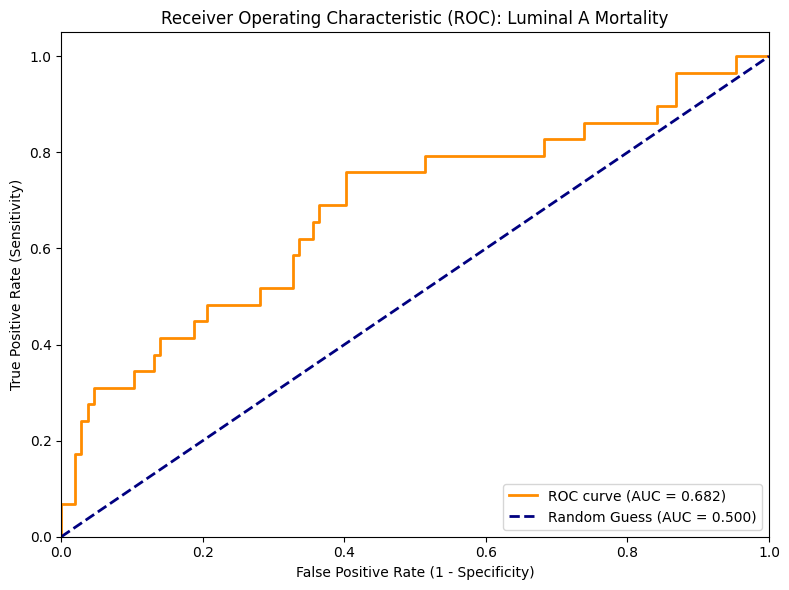

In [ ]:
test_proba = winning_model.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC): Luminal A Mortality')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ROC_Curve_LumA.pdf", format='pdf', dpi=300)
plt.show()

In [ ]:
# INCREMENTAL FEATURE GAIN ANALYSIS (Forward Feature Evaluation)

In [ ]:
# Extract and sort the feature importances from the winning Random Forest
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': winning_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_5_features = feature_importances['Feature'].head(5).tolist()

In [ ]:
# CLINICAL VALUE ADDITION TABLE (Baseline Assumption: Genomic PAM50 Status (Luminal A) = 'Low Risk)

In [ ]:
incremental_features = []
previous_auc = 0.500
auc_scores = [previous_auc]
gain_scores = [0.0]
feature_labels = ['PAM50\n(Baseline)']

# Loop through the top 5 features, adding them one by one
for i, feature in enumerate(top_5_features):
    incremental_features.append(feature)

    X_train_subset = X_train_scaled[incremental_features]
    X_test_subset = X_test_scaled[incremental_features]

    mini_rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    mini_rf.fit(X_train_subset, y_train)

    mini_proba = mini_rf.predict_proba(X_test_subset)[:, 1]
    current_auc = roc_auc_score(y_test, mini_proba)
    gain = current_auc - previous_auc

    # Store for plotting
    auc_scores.append(current_auc)
    gain_scores.append(gain)
    feature_labels.append(f"+ {feature}")

    previous_auc = current_auc

/tmp/ipykernel_2896/3110583410.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gain_scores[1:], y=feature_labels[1:], ax=ax1, palette="Reds_r")


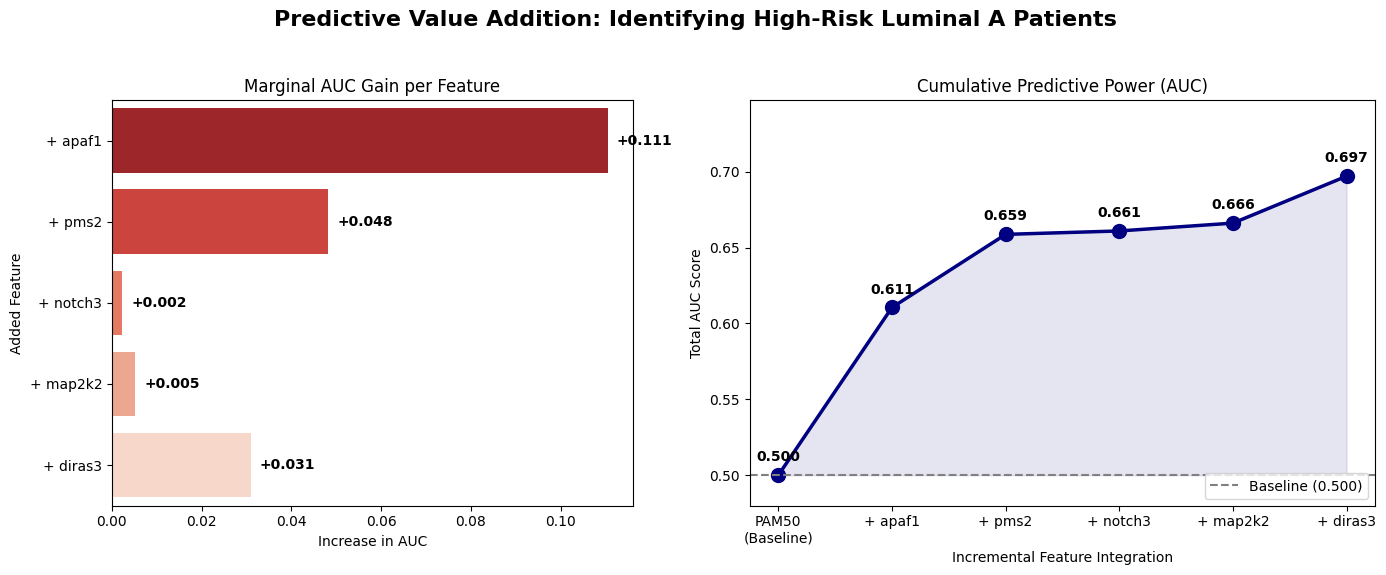

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle("Predictive Value Addition: Identifying High-Risk Luminal A Patients", fontsize=16, fontweight='bold')

# Horizontal Bar Chart of Marginal Gains
sns.barplot(x=gain_scores[1:], y=feature_labels[1:], ax=ax1, palette="Reds_r")
ax1.set_title("Marginal AUC Gain per Feature", fontsize=12)
ax1.set_xlabel("Increase in AUC")
ax1.set_ylabel("Added Feature")
for i, v in enumerate(gain_scores[1:]):
    ax1.text(v + 0.002, i, f"+{v:.3f}", color='black', va='center', fontweight='bold')

# Line Plot of Cumulative AUC
ax2.plot(feature_labels, auc_scores, marker='o', markersize=10, linestyle='-', color='navy', linewidth=2.5)
ax2.fill_between(feature_labels, 0.500, auc_scores, color='navy', alpha=0.1)
ax2.axhline(y=0.500, color='gray', linestyle='--', label='Baseline (0.500)')
ax2.set_title("Cumulative Predictive Power (AUC)", fontsize=12)
ax2.set_xlabel("Incremental Feature Integration")
ax2.set_ylabel("Total AUC Score")
ax2.set_ylim(0.48, max(auc_scores) + 0.05)
ax2.legend(loc="lower right")

# Annotate the line chart points
for i, txt in enumerate(auc_scores):
    ax2.annotate(f"{txt:.3f}", (feature_labels[i], auc_scores[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("Clinical_Value_Addition_Dashboard.pdf", format='pdf', dpi=300)
plt.show()

In [ ]:
# XAI (SHAP)

In [ ]:
# TreeExplainer calculates the exact marginal contribution of every clinical feature.
explainer = shap.TreeExplainer(winning_model)
shap_values = explainer.shap_values(X_test_scaled)

In [ ]:
# For binary classification in Random Forest, shap_values is a list.
# Index 1 is the explanation for the positive class (target_mortality = 1).
hap_values_disease_death = shap_values[1] if isinstance(shap_values, list) else shap_values

<Figure size 1000x600 with 0 Axes>

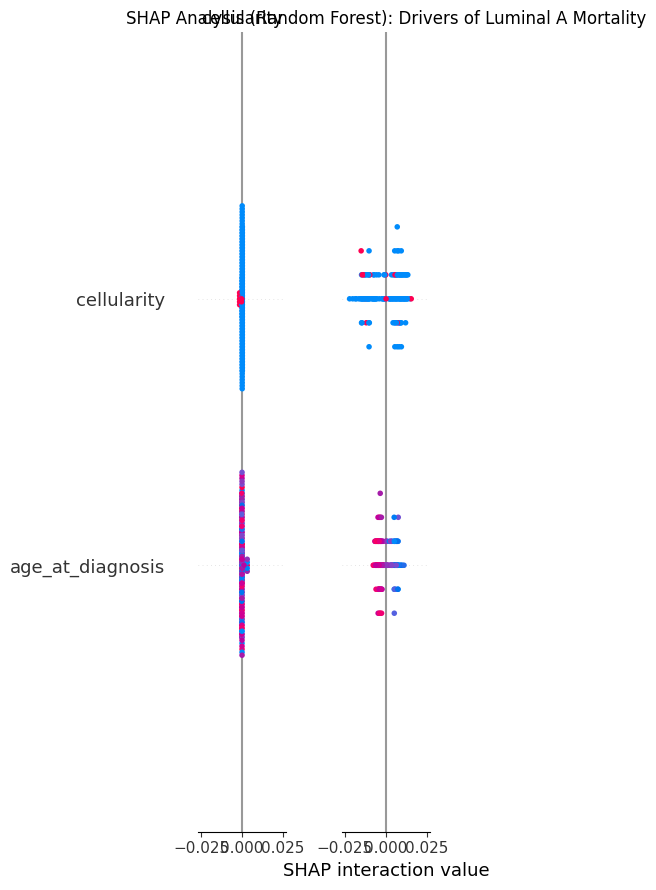

In [ ]:
"""
Plot the top 10 most important features
Each dot is a patient.
Red dots = high feature value (e.g., high NPI). Blue dots = low feature value.
Dots pushed to the right mean that feature increased the risk of death.
"""
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_disease_death,
    X_test_scaled,
    feature_names=features,
    max_display=10,
    show=False
)
plt.title("SHAP Analysis (Random Forest): Drivers of Luminal A Mortality")
plt.tight_layout()
plt.savefig("SHAP_Luminal_A_Final.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()